# Replicate `vacc_sweep.py` — single α

Pick a `NETWORK`, `KERNEL`, and `ALPHA`. The notebook runs ONE (λ × ν) sweep at that α and plots a single heatmap. Grid defaults (`N_LAM=20`, `N_NU=15`, `T_MAX=300`) are smaller than `vacc_sweep.py` so the sweep finishes in a couple minutes serially. Crank them up to match the cluster runs (50 × 40, T=1000) if you want full resolution.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

import vacc_sweep as vs

NETWORK = "Thiers13"            # Thiers13, LyonSchool, Synthetic_poisson_k{2,3,5}
KERNEL  = "diversity_tension"   # diversity_tension, tension_shifted, mixture
ALPHA   = 0.1

N_LAM = 20      # vacc_sweep.py uses 50
N_NU  = 15      # vacc_sweep.py uses 40
T_MAX = 300.0   # vacc_sweep.py uses 1000

lam_grid = np.logspace(-3, 0, N_LAM)
nu_grid  = np.linspace(1.0, 10.0, N_NU)

gm, pn, mmax, nmax, state_meta = vs.load_group_statistics(NETWORK)
print(f"{NETWORK}: nmax={nmax}, mmax={mmax}")

Thiers13: nmax=6, mmax=5


In [2]:
# Single-alpha serial sweep (no Pool, no multiple alphas).
w_mat  = vs.build_switching_matrix(nmax, ALPHA, KERNEL)
I_low  = np.zeros((N_LAM, N_NU))
I_high = np.zeros((N_LAM, N_NU))

t0 = time.time()
for j, nu in enumerate(nu_grid):
    for i, lam in enumerate(lam_grid):
        _, I_low[i, j],  _ = vs.run_to_stationarity(lam, nu, w_mat, state_meta, vs.I0_LOW,  t_max=T_MAX)
        _, I_high[i, j], _ = vs.run_to_stationarity(lam, nu, w_mat, state_meta, vs.I0_HIGH, t_max=T_MAX)
    print(f"  nu={nu:.2f} [{j+1}/{N_NU}]  elapsed={time.time()-t0:.0f}s", flush=True)

delta = I_high - I_low
n_bi  = int((delta > 0.05).sum())
print(f"\nDone. alpha={ALPHA:g}  max δI={delta.max():.4f}  bistable_cells={n_bi}")

  nu=1.00 [1/15]  elapsed=4s
  nu=1.64 [2/15]  elapsed=8s
  nu=2.29 [3/15]  elapsed=13s
  nu=2.93 [4/15]  elapsed=18s
  nu=3.57 [5/15]  elapsed=23s
  nu=4.21 [6/15]  elapsed=29s
  nu=4.86 [7/15]  elapsed=36s
  nu=5.50 [8/15]  elapsed=43s
  nu=6.14 [9/15]  elapsed=50s
  nu=6.79 [10/15]  elapsed=58s
  nu=7.43 [11/15]  elapsed=67s
  nu=8.07 [12/15]  elapsed=76s
  nu=8.71 [13/15]  elapsed=85s
  nu=9.36 [14/15]  elapsed=95s
  nu=10.00 [15/15]  elapsed=107s

Done. alpha=0.1  max δI=0.1236  bistable_cells=42


## Heatmap

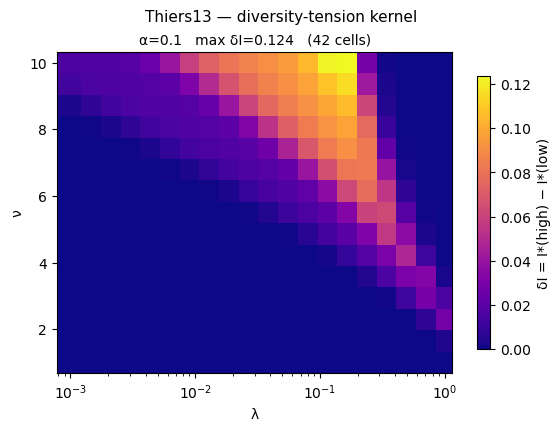

In [3]:
fig, ax = plt.subplots(figsize=(5.5, 4.2), constrained_layout=True)
im = ax.pcolormesh(lam_grid, nu_grid, delta.T, vmin=0, vmax=max(delta.max(), 1e-12),
                   cmap="plasma", shading="auto")
ax.set_xscale("log")
ax.set_xlabel("λ")
ax.set_ylabel("ν")
ax.set_title(f"α={ALPHA:.2g}   max δI={delta.max():.3f}   ({n_bi} cells)", fontsize=10)
cbar = fig.colorbar(im, ax=ax, shrink=0.85)
cbar.set_label("δI = I*(high) − I*(low)")
fig.suptitle(f"{NETWORK} — {KERNEL.replace('_','-')} kernel", fontsize=11)
plt.show()